# Hitpoints Data Histogram
This notebook loads the hitpoints data from the CSV, flattens all columns into a single column, removes the header row, and plots a histogram of the frequency (%) of the data. The histogram is saved as an SVG file in the /Images folder.

C:\Users\mrast\AppData\Local\Temp\ipykernel_24624\2631008179.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_24624\2631008179.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.1f}" for y in ax.get_yticks()], fontsize=14)


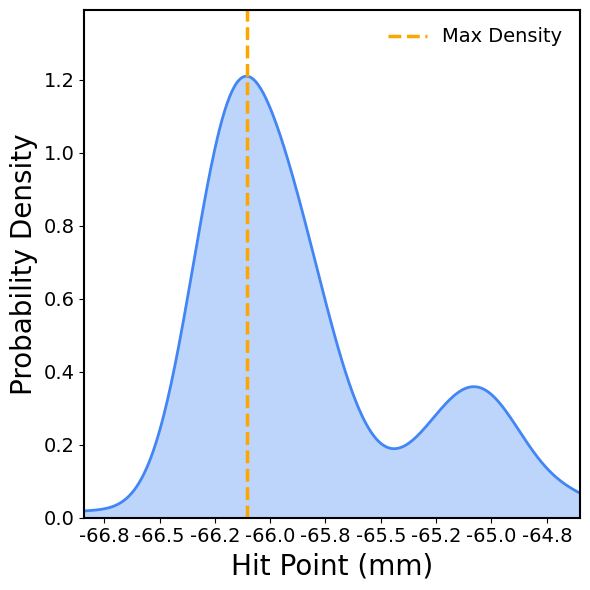

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde
from matplotlib.ticker import PercentFormatter

# --- Style settings to match plot4_error_distribution.svg ---
LABEL_FS = 26
GOOGLE_BLUE = '#4285f4'
GOOGLE_ORANGE = '#FFA500'

# Load CSV, skip the first row (header with cell_1, cell_2, ...), no header
csv_path = Path('../results/Auto-runs/hitpoints.csv')
df = pd.read_csv(csv_path, header=None, skiprows=1)

# Flatten all columns into a single column, drop NaNs
data = df.values.flatten()
data = pd.Series(data).dropna().astype(float)

# KDE curve (like panel E)
if data.size >= 2 and np.nanstd(data) > 0:
    kde = gaussian_kde(data)
    x_curve = np.linspace(data.min(), data.max(), 400)
    y_curve = kde(x_curve)
    # Find the hit point with max density
    max_idx = np.argmax(y_curve)
    max_hitpoint = x_curve[max_idx]
else:
    x_curve = np.array([])
    y_curve = np.array([])
    max_hitpoint = None

fig, ax = plt.subplots(figsize=(6, 6))

# Fill under the curve for area effect (if KDE is valid)
if x_curve.size > 0:
    ax.fill_between(x_curve, 0, y_curve, color=GOOGLE_BLUE, alpha=0.35, linewidth=0)
    ax.plot(x_curve, y_curve, color=GOOGLE_BLUE, lw=2.0)
    # Draw vertical line at max density
    ax.axvline(max_hitpoint, color=GOOGLE_ORANGE, lw=2.5, linestyle='--', label='Max Density')

# Set axis limits and labels to match style
ax.set_xlim(data.min(), data.max())
if y_curve.size > 0:
    ax.set_ylim(0, float(np.nanmax(y_curve)) * 1.15)

ax.set_xlabel('Hit Point (mm)', fontsize=20)
ax.set_ylabel('Probability Density', fontsize=20)

# Percent y-axis formatter, no symbol, 0 decimals
ax.yaxis.set_major_formatter(PercentFormatter(decimals=1, symbol=""))
ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
ax.set_yticklabels([f"{y:.1f}" for y in ax.get_yticks()], fontsize=14)

# Set axis line width and color
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# Set grid off (to match style)
ax.grid(False)

# Add legend for max density line if present
if x_curve.size > 0:
    ax.legend(fontsize=14, frameon=False)

# Tight layout and save as SVG
svg_path = Path('../Images/hitpoints_histogram.svg')
plt.tight_layout()
plt.savefig(svg_path, format='svg')
plt.show()